# 03 — Full Fine-tuning IndoBERT with Class Weights

This notebook performs full fine-tuning on the `indobenchmark/indobert-base-p1` model.
- **Goal**: Improve Recall for minority classes (Netral & Negatif).
- **Strategy**: Full BERT update + **Weighted CrossEntropy Loss**.
- **Output**: Fine-tuned model in `outputs/indobert_finetuned`.

In [9]:
## 0. Google Colab Setup
import sys, os
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Google Colab detected — mounting Drive & installing packages …")
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_PROJECT = "/content/drive/MyDrive/xai_lime_vs_shap"
    if os.path.isdir(DRIVE_PROJECT):
        os.chdir(DRIVE_PROJECT)
        print(f"CWD set to: {DRIVE_PROJECT}")
    
    !pip install -q transformers datasets accelerate
else:
    print("Local environment — no Colab setup needed.")

Google Colab detected — mounting Drive & installing packages …
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD set to: /content/drive/MyDrive/xai_lime_vs_shap


In [10]:
## 1. Imports & Config
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding,
    pipeline
)
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

MODEL_NAME = "indobenchmark/indobert-base-p1"
OUTPUT_DIR = "outputs/indobert_finetuned"
DATA_PATH = "data/processed/tokopedia_reviews_clean.csv"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

Using device: cuda


In [11]:
## 2. Load & Preprocess Data
df = pd.read_csv(DATA_PATH)

LABEL_MAP = {"Positif": 0, "Negatif": 1, "Netral": 2}
ID2LABEL = {0: "Positif", 1: "Negatif", 2: "Netral"}
df['label'] = df['sentiment_label'].map(LABEL_MAP)
df = df[['review_text_clean', 'label']].dropna()

# Convert to Hugging Face Dataset
raw_dataset = Dataset.from_pandas(df)

# Split into Train/Test (80/20)
train_test_split = raw_dataset.train_test_split(test_size=0.2, seed=42)
datasets = DatasetDict({
    'train': train_test_split['train'],
    'test': train_test_split['test']
})

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(examples["review_text_clean"], truncation=True, max_length=128)

tokenized_datasets = datasets.map(tokenize_fn, batched=True)
print("Datasets ready.")

Map:   0%|          | 0/1247 [00:00<?, ? examples/s]

Map:   0%|          | 0/312 [00:00<?, ? examples/s]

Datasets ready.


In [12]:
## 3. Calculate Class Weights
labels = np.array(datasets['train']['label'])
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(labels), 
    y=labels
)
class_weights_t = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print("Class Weights (Positif, Negatif, Netral):")
print(class_weights)

Class Weights (Positif, Negatif, Netral):
[0.36558194 6.70430108 8.65972222]


In [13]:
## 4. Custom Trainer with Weighted Loss

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Use class weights in CrossEntropy
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_t)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    f1 = f1_score(labels, predictions, average='macro')
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1_macro": f1}

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
## 5. Training

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=2e-5,          
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",      
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)
trainer.tokenizer = tokenizer

print("Starting Fine-tuning...")
trainer.train()

Starting Fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.772270,1.093899,0.932692,0.645631
2,0.305110,0.661995,0.939103,0.757774
3,0.245581,0.824083,0.945513,0.773200
4,0.025586,1.173830,0.948718,0.755753
5,0.040559,1.163000,0.939103,0.735372


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=390, training_loss=0.24824800861951632, metrics={'train_runtime': 142.7937, 'train_samples_per_second': 43.664, 'train_steps_per_second': 2.731, 'total_flos': 108741383850582.0, 'train_loss': 0.24824800861951632, 'epoch': 5.0})


Final Classification Report:


              precision    recall  f1-score   support

     Positif       0.99      0.96      0.97       281
     Negatif       0.64      0.82      0.72        17
      Netral       0.53      0.64      0.58        14

    accuracy                           0.94       312
   macro avg       0.72      0.81      0.76       312
weighted avg       0.95      0.94      0.94       312



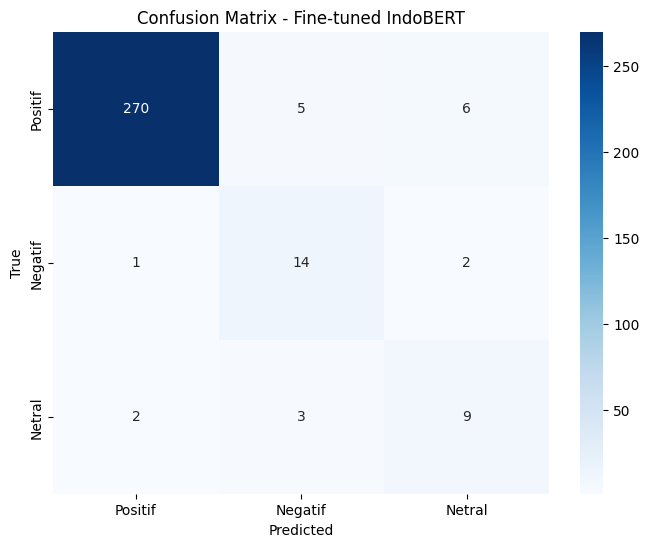

In [15]:
## 6. Evaluation
print("\nFinal Classification Report:")
preds_output = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(preds_output.predictions, axis=-1)
true_labels = tokenized_datasets["test"]["label"]

target_names = list(LABEL_MAP.keys())
print(classification_report(true_labels, preds, target_names=target_names))

## 7. Confusion Matrix Visualization
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Fine-tuned IndoBERT")
plt.show()

In [16]:
## 8. Test on Raw Sentences
classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=0 if DEVICE == "cuda" else -1)

test_sentences = [
    "Barangnya bagus sesuai deskripsi, mantap.", # Positif
    "Kecewa banget, barang rusak pas sampai penipu.", # Negatif
    "Kualitas oke tapi pengiriman lama banget sih.", # Netral/Negatif context
    "Biasa aja, standarlah untuk harga segini.", # Netral
]

print("Test Results:")
for text in test_sentences:
    res = classifier(text)[0]
    label_idx = int(res['label'].split('_')[-1])
    print(f"Text: {text}")
    print(f"Prediction: {ID2LABEL[label_idx]} (Score: {res['score']:.4f})\n")

Test Results:
Text: Barangnya bagus sesuai deskripsi, mantap.
Prediction: Positif (Score: 0.9970)

Text: Kecewa banget, barang rusak pas sampai penipu.
Prediction: Negatif (Score: 0.9576)

Text: Kualitas oke tapi pengiriman lama banget sih.
Prediction: Netral (Score: 0.9870)

Text: Biasa aja, standarlah untuk harga segini.
Prediction: Positif (Score: 0.5656)



In [17]:
## 9. Save Assets for next stage
trainer.save_model(OUTPUT_DIR)
print(f"Full fine-tuned model saved to {OUTPUT_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Full fine-tuned model saved to outputs/indobert_finetuned
